<a href="https://colab.research.google.com/github/marimsw/dataset_CIFAR10/blob/main/1_datasets_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from torchvision import datasets
data_path = './root/.cache/kagglehub/datasets/ayush1220/cifar10/versions/2'
cifar10 = datasets.CIFAR10(data_path, train=True, download=True) # <1>
cifar10_val = datasets.CIFAR10(data_path, train=False, download=True) # <2>

100%|██████████| 170M/170M [00:04<00:00, 42.3MB/s]


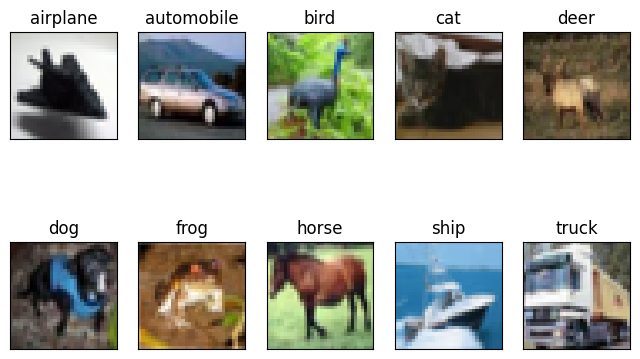

In [4]:
import matplotlib.pyplot as plt

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

fig = plt.figure(figsize=(8,5))
num_classes = 10
for i in range(num_classes):
    ax = fig.add_subplot(2, 5, 1 + i, xticks=[], yticks=[])
    ax.set_title(class_names[i])
    img = next(img for img, label in cifar10 if label == i)
    plt.imshow(img)
plt.show()

In [5]:
type(cifar10).__mro__

(torchvision.datasets.cifar.CIFAR10,
 torchvision.datasets.vision.VisionDataset,
 torch.utils.data.dataset.Dataset,
 typing.Generic,
 object)

In [6]:
len(cifar10)

50000

In [7]:
img, label = cifar10[99]
img, label, class_names[label]

(<PIL.Image.Image image mode=RGB size=32x32>, 1, 'automobile')

In [8]:
img1,label1= cifar10[4]

In [9]:
img2, label2 = cifar10[3]
img2, label2, class_names[label2]

(<PIL.Image.Image image mode=RGB size=32x32>, 4, 'deer')

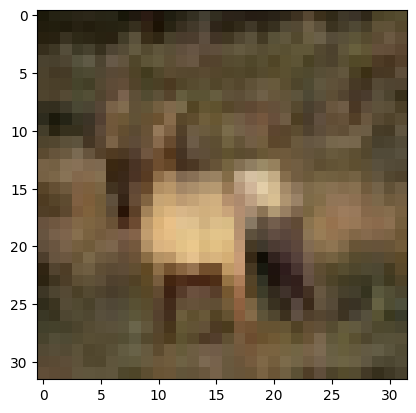

In [10]:
plt.imshow(img2)
plt.show()

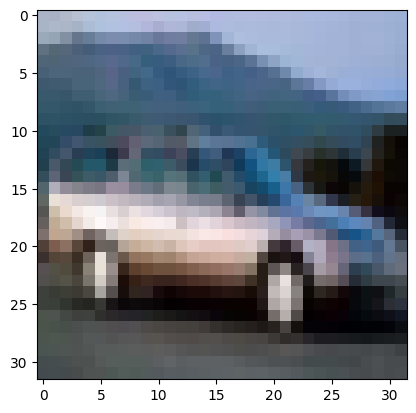

In [11]:
plt.imshow(img1)
plt.show()

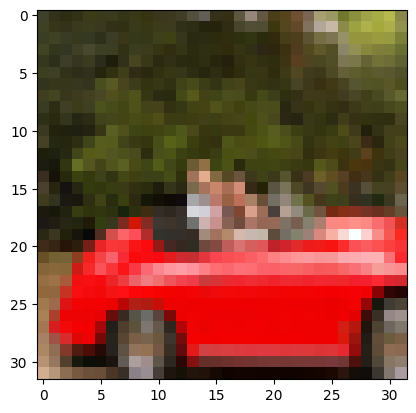

In [12]:
plt.imshow(img)
plt.show()

In [13]:
from torchvision import transforms
dir(transforms)

['AugMix',
 'AutoAugment',
 'AutoAugmentPolicy',
 'CenterCrop',
 'ColorJitter',
 'Compose',
 'ConvertImageDtype',
 'ElasticTransform',
 'FiveCrop',
 'GaussianBlur',
 'Grayscale',
 'InterpolationMode',
 'Lambda',
 'LinearTransformation',
 'Normalize',
 'PILToTensor',
 'Pad',
 'RandAugment',
 'RandomAdjustSharpness',
 'RandomAffine',
 'RandomApply',
 'RandomAutocontrast',
 'RandomChoice',
 'RandomCrop',
 'RandomEqualize',
 'RandomErasing',
 'RandomGrayscale',
 'RandomHorizontalFlip',
 'RandomInvert',
 'RandomOrder',
 'RandomPerspective',
 'RandomPosterize',
 'RandomResizedCrop',
 'RandomRotation',
 'RandomSolarize',
 'RandomVerticalFlip',
 'Resize',
 'TenCrop',
 'ToPILImage',
 'ToTensor',
 'TrivialAugmentWide',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 '_functional_pil',
 '_functional_tensor',
 '_presets',
 'autoaugment',
 'functional',
 'transforms']

In [14]:
from torchvision import transforms
to_tensor = transforms.ToTensor()
img_t = to_tensor(img)
img_t.shape

torch.Size([3, 32, 32])

In [15]:
tensor_cifar10 = datasets.CIFAR10(data_path, train= True, download= False,
                                  transform= transforms.ToTensor())

In [16]:
img_t, _ = tensor_cifar10[99]
type(img_t)

torch.Tensor

In [17]:
img_t.shape, img_t.dtype

(torch.Size([3, 32, 32]), torch.float32)

In [18]:
img_t.min(), img_t.max()

(tensor(0.), tensor(1.))

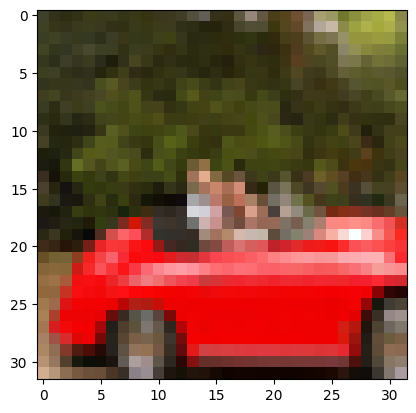

In [19]:
plt.imshow(img_t.permute(1,2,0))
plt.show()

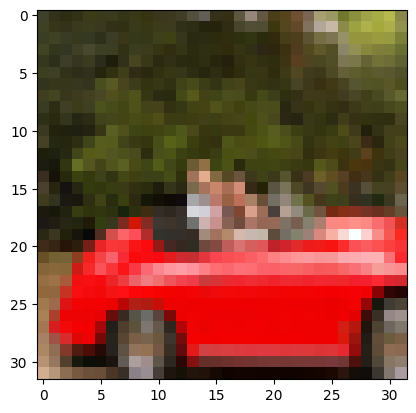

In [20]:
plt.imshow(img_t.permute(1, 2, 0))  # <1>
plt.show()

In [21]:
import torch

In [23]:
imgs = torch.stack([img_t for img_t, _ in tensor_cifar10], dim=3)
imgs.shape

torch.Size([3, 32, 32, 50000])

In [25]:
imgs.view(3, -1).std(dim=1)

tensor([0.2470, 0.2435, 0.2616])

In [27]:
transforms.Normalize((0.4915, 0.4823, 0.4468), (0.2470, 0.2435, 0.2616))

Normalize(mean=(0.4915, 0.4823, 0.4468), std=(0.247, 0.2435, 0.2616))

In [32]:
transformed_cifar10 = datasets.CIFAR10(
    data_path, train=True, download=False,
    transform= transforms.Compose([
    transforms. ToTensor(),
    transforms.Normalize((0.4915, 0.4823, 0.4468),
                          (0.2470, 0.2435, 0.2616))
    ]
))

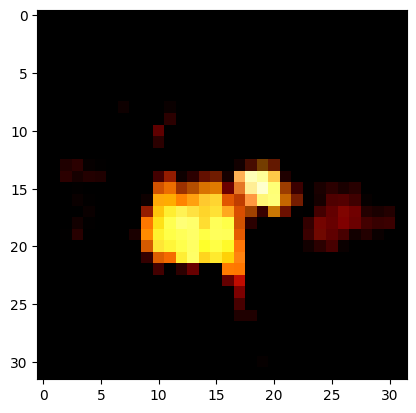

In [33]:
img_t, _ = transformed_cifar10[3]
plt.imshow(img_t.permute(1,2, 0))
plt.show()

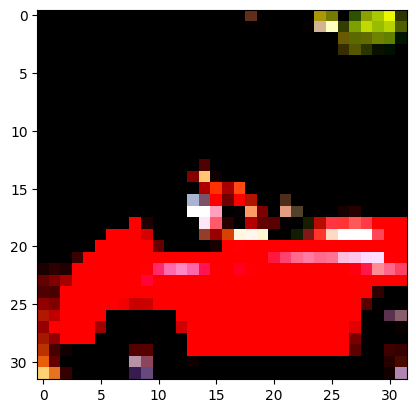

In [34]:
img_t, _ = transformed_cifar10[99]

plt.imshow(img_t.permute(1, 2, 0))
plt.show()